# Diagnose recompilation and host synchronization

CPU companion; no accelerator is required. TPU execution not validated.

- Record shapes, dtypes and dynamic/static choices beside observed tracing.
- Separate Python trace diagnostics from compilation evidence.
- Keep ordinary numerical hyperparameters dynamic when their values need not determine program structure.
- Compare per-step host consumption with one final host consumption while checking equivalent results.

A new batch size makes one call pause; reading a metric makes another loop wait. Those delays can look similar, but they have different causes. We’ll record the shapes, dtypes and static choices of each call, then inspect where Python asks for device values. The evidence will guide the change.

## The idea

Slow steps can come from preparing new program specializations or from waiting for already-compiled work. Use a controlled call ledger and timing boundaries to separate those causes.

## Distinguish new tracing from host waiting

Change only array values while keeping shapes, dtypes and static choices fixed. Then change one signature component and record the observed trace behavior. Changing everything together makes the cause ambiguous.

Inspect host reads and logging next. Converting device results into Python values can force a wait even when no retracing occurs. That delay needs a different intervention from reducing signature variation.

Trace counts describe observed Python tracing. They are not a universal count of compiler work or a guarantee of cache reuse after restart. Combine the ledger with a trace of completed work before deciding which change improves the actual workload.

### Pause and reason

If the trace count stays constant but a step is slow, what should you inspect?

<details><summary>Compare your reasoning</summary>

Inspect synchronization, transfers, data preparation and logging. A stable trace count does not rule out those boundaries.

</details>

## A call signature is different from its numerical data

Our score is the sum of squared scaled inputs. With $x=[0, \ldots, 7]$ and gain $1$, the answer is $140$; with gain $2$ it becomes $560$. Passing a float32 scalar gain keeps its abstract shape and dtype unchanged when the value changes. The transformed computation can read that value at execution time.

An array of twelve elements has a different shape from the eight-element array. Ordinary jit specializes to these shapes, so this is a plausible cause of new staging work. A ledger records the actual calls before attributing a pause. Sharding, compiler options, callable identity and other context can matter too; the ledger is a diagnosis aid, not a full cache-key specification.

```text
call → (shape, dtype, static choices) → specialization
             dynamic values → execution of that program
```

## Observe tracing without mislabeling compilation

The score function appends its input signature to a Python list. This is a deliberate authoring diagnostic: Python runs while JAX traces the function, whereas the compiled numerical operations can run later without replaying that Python append. Never use this list as optimizer state or a reliable callback from accelerator execution.

We log the change in list length around each call, but assert numerical answers rather than a fixed event count. Cache state and implementation details affect observations. A trace event does not prove that a new executable was compiled, and absence of an event is not proof that no compiler activity occurred. Enable public jax_log_compiles diagnostics or obtain a profiler trace for stronger evidence, recording exactly which log event supports a claim.

**Capture public compilation diagnostics on macOS/Linux**

```POSIX shell
JAX_LOG_COMPILES=1 python diagnosis.py 2> compile.log
```

**Expected:** The usual ledger appears in the terminal. compile.log contains JAX diagnostics, including tracing and compilation messages when observed. Read the named stage in each line; do not count every line as a compile.

**Capture diagnostics in PowerShell**

```PowerShell
$env:JAX_LOG_COMPILES="1"
python diagnosis.py 2> compile.log
Remove-Item Env:JAX_LOG_COMPILES
```

**Expected:** The ledger appears in the terminal and diagnostics are captured in compile.log. Removing the environment variable restores the shell setting after the run.

## Choose static arguments for structure rather than convenience

A Boolean selecting one of two Python branches can be static so tracing selects the branch. Its value then becomes part of specialization, so changing that choice can trigger staging. Static arguments must be hashable and are unsuitable for arbitrary numerical array data. Avoid declaring a rapidly changing scalar gain static just to make Python logic convenient.

If the gain only participates in arithmetic, pass it as a typed scalar array as we did. If a runtime Boolean chooses arithmetic, express the selection with lax.cond or another appropriate array operation. Static metadata and dynamic numerical values serve different purposes; changing one into the other can change the number of specializations and the program itself.

## A host metric is an explicit synchronization boundary

`float(score)` needs the scalar contents in Python. That read waits for any outstanding work needed to produce it. Keeping a scalar loss as a JAX array allows later device computations to consume it without Python inspecting its value. A chain can then be synchronized once at the final output.

The exercise compares six dependent updates with host consumption after each step against six updates with a final wait. Both variants must produce the same scalar. Their wall-clock boundaries include different waits and conversion overhead; we record both but assert no speed ordering. Removing intermediate logging also removes observability, so production systems may use bounded logging intervals instead of silently dropping metrics.

## Prepare a trace ledger

Create diagnosis.py in your activated course environment and add this block.

In [1]:
import json
import time
import numpy as np
import jax
import jax.numpy as jnp
cpu = jax.devices("cpu")[0]
trace_events = []
def score(x, gain):
    # Authoring diagnostic: this Python effect happens during tracing.
    # It is NOT model state and does not count executable compilations.
    trace_events.append({"shape": list(x.shape), "dtype": str(x.dtype)})
    return jnp.sum((x * gain)**2)
compiled_score = jax.jit(score)
x8 = jax.device_put(np.arange(8, dtype=np.float32), cpu)
x12 = jax.device_put(np.arange(12, dtype=np.float32), cpu)
jax.block_until_ready((x8, x12))


This CPU experiment deliberately keeps the trace ledger outside numerical state. Run it in a fresh process when comparing observations.

## Record call signatures and observed traces

Append this block to the same file. Run the assembled file with python diagnosis.py.

In [2]:
call_rows = []
def observed_call(label, x, gain):
    before = len(trace_events)
    result = compiled_score(x, jax.device_put(np.float32(gain), cpu))
    result.block_until_ready()
    expected = np.sum((np.asarray(x) * np.float32(gain))**2)
    np.testing.assert_allclose(np.asarray(result), expected, rtol=2e-5, atol=2e-5)
    call_rows.append({"label": label, "shape": list(x.shape), "dtype": str(x.dtype),
                      "observed_trace_delta": len(trace_events) - before,
                      "result": float(result)})
    return result


The ledger relates each controlled signature change to the observed Python event delta, with an independent NumPy value check.

## Run the controlled call sequence

Append this block to the same file. Run the assembled file with python diagnosis.py.

In [3]:
observed_call("initial signature", x8, 1.)
observed_call("same signature changed data", x8 + 1., 1.)
observed_call("same signature changed dynamic gain", x8, 2.)
observed_call("different input shape", x12, 1.)
print(json.dumps({"jax": jax.__version__, "backend": str(cpu),
                  "calls": call_rows, "python_trace_events": trace_events}, indent=2))
assert call_rows[0]["result"] == 140.
assert call_rows[2]["result"] == 560.
assert call_rows[3]["result"] == 506.


{
  "jax": "0.9.2",
  "backend": "TFRT_CPU_0",
  "calls": [
    {
      "label": "initial signature",
      "shape": [
        8
      ],
      "dtype": "float32",
      "observed_trace_delta": 1,
      "result": 140.0
    },
    {
      "label": "same signature changed data",
      "shape": [
        8
      ],
      "dtype": "float32",
      "observed_trace_delta": 0,
      "result": 204.0
    },
    {
      "label": "same signature changed dynamic gain",
      "shape": [
        8
      ],
      "dtype": "float32",
      "observed_trace_delta": 0,
      "result": 560.0
    },
    {
      "label": "different input shape",
      "shape": [
        12
      ],
      "dtype": "float32",
      "observed_trace_delta": 1,
      "result": 506.0
    }
  ],
  "python_trace_events": [
    {
      "shape": [
        8
      ],
      "dtype": "float32"
    },
    {
      "shape": [
        12
      ],
      "dtype": "float32"
    }
  ]
}


Inspect the event deltas on your own environment. The required outputs are checked numeric scores, not a fabricated trace or compilation count.

## Run the example

In [4]:
import json
import time
import numpy as np
import jax
import jax.numpy as jnp
cpu = jax.devices("cpu")[0]
trace_events = []
def score(x, gain):
    # Authoring diagnostic: this Python effect happens during tracing.
    # It is NOT model state and does not count executable compilations.
    trace_events.append({"shape": list(x.shape), "dtype": str(x.dtype)})
    return jnp.sum((x * gain)**2)
compiled_score = jax.jit(score)
x8 = jax.device_put(np.arange(8, dtype=np.float32), cpu)
x12 = jax.device_put(np.arange(12, dtype=np.float32), cpu)
jax.block_until_ready((x8, x12))

call_rows = []
def observed_call(label, x, gain):
    before = len(trace_events)
    result = compiled_score(x, jax.device_put(np.float32(gain), cpu))
    result.block_until_ready()
    expected = np.sum((np.asarray(x) * np.float32(gain))**2)
    np.testing.assert_allclose(np.asarray(result), expected, rtol=2e-5, atol=2e-5)
    call_rows.append({"label": label, "shape": list(x.shape), "dtype": str(x.dtype),
                      "observed_trace_delta": len(trace_events) - before,
                      "result": float(result)})
    return result

observed_call("initial signature", x8, 1.)
observed_call("same signature changed data", x8 + 1., 1.)
observed_call("same signature changed dynamic gain", x8, 2.)
observed_call("different input shape", x12, 1.)
print(json.dumps({"jax": jax.__version__, "backend": str(cpu),
                  "calls": call_rows, "python_trace_events": trace_events}, indent=2))
assert call_rows[0]["result"] == 140.
assert call_rows[2]["result"] == 560.
assert call_rows[3]["result"] == 506.


{
  "jax": "0.9.2",
  "backend": "TFRT_CPU_0",
  "calls": [
    {
      "label": "initial signature",
      "shape": [
        8
      ],
      "dtype": "float32",
      "observed_trace_delta": 1,
      "result": 140.0
    },
    {
      "label": "same signature changed data",
      "shape": [
        8
      ],
      "dtype": "float32",
      "observed_trace_delta": 0,
      "result": 204.0
    },
    {
      "label": "same signature changed dynamic gain",
      "shape": [
        8
      ],
      "dtype": "float32",
      "observed_trace_delta": 0,
      "result": 560.0
    },
    {
      "label": "different input shape",
      "shape": [
        12
      ],
      "dtype": "float32",
      "observed_trace_delta": 1,
      "result": 506.0
    }
  ],
  "python_trace_events": [
    {
      "shape": [
        8
      ],
      "dtype": "float32"
    },
    {
      "shape": [
        12
      ],
      "dtype": "float32"
    }
  ]
}


Expected: A JSON ledger of four calls and observed Python trace events. Checked scores include $140$, $560$ and $506$; event deltas are recorded rather than fixed by the lesson.

## A new value is not necessarily a new trace

Predict: Which call changes the input signature?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'bar', 'labels': ['initial', 'new values', 'new gain', 'new shape'], 'ylabel': 'observed Python trace events', 'series': [{'label': 'trace delta', 'y': [r['observed_trace_delta'] for r in call_rows]}]}

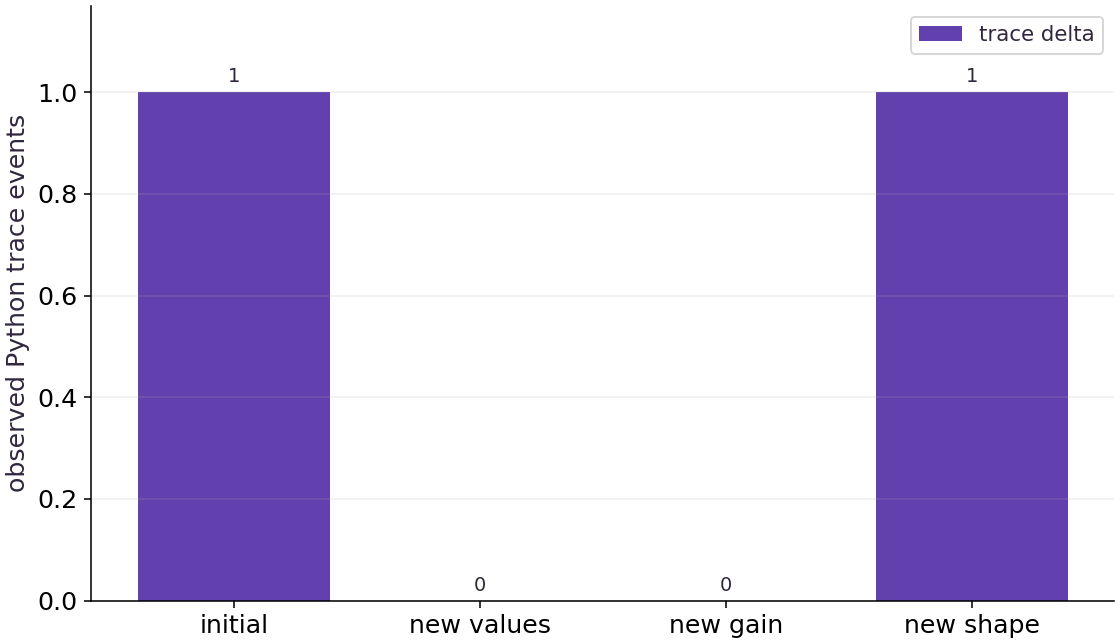

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each bar reports the additional Python tracing events observed during one call category. The sequence is $(1,0,0,1)$: the initial call traces, new array values do not, a new dynamic gain does not, and a new input shape triggers another trace.

The two zero-height bars are meaningful observations. The calls still execute and can return changed values; zero means the trace counter did not increase for those calls.

### Connect it to the computation

The existing specialization can accept compatible dynamic values without rerunning the traced Python body. Changing the example’s shape from length $8$ to length $12$ changes the abstract input signature, so a new trace is observed. This isolates shape from ordinary value changes.

The vertical axis counts Python traces, not seconds, device kernels, or an exact count of backend compilations. To diagnose runtime overhead, combine this kind of counter with synchronized measurements or a profiler. A changed answer alone is not evidence of retracing.

## Contrast static branch metadata with a dynamic gain

Predict: Which changes require a different Python branch to be selected while tracing? Is that the same as changing gain from $1$ to $2$?

In [7]:
branch_events = []
def branch_score(x, square):
    branch_events.append({"shape": list(x.shape), "square": square})
    return jnp.sum(x**2) if square else jnp.sum(x)
static_score = jax.jit(branch_score, static_argnames=("square",))
for square in [True, True, False]:
    out = static_score(x8, square=square)
    np.testing.assert_allclose(np.asarray(out), 140. if square else 28.)
print("Static branch trace observations:", branch_events)


Static branch trace observations: [{'shape': [8], 'square': True}, {'shape': [8], 'square': False}]


Expected: Correct scores for both branches, plus the trace events observed in this process.

The static Boolean controls Python program structure. The earlier numerical gain was dynamic arithmetic data. These are distinct specialization choices; the printed diagnostic is not an executable compilation count.

## Keep a metric on device until the reporting boundary

Predict: Will six per-step host reads and one final read produce the same value? Must one be faster on this CPU?

In [8]:
update = jax.jit(lambda value: 0.9 * value + 1.)
initial = jax.device_put(np.float32(0.), cpu)
update(initial).block_until_ready()
def metric_run(read_each):
    value = initial
    observed = []
    start = time.perf_counter()
    for _ in range(6):
        value = update(value)
        if read_each:
            observed.append(float(value))
    value.block_until_ready()
    elapsed = time.perf_counter() - start
    return value, elapsed, observed
read_result, read_seconds, metrics = metric_run(True)
final_result, final_seconds, _ = metric_run(False)
reference_value = 10. * (1. - 0.9**6)
np.testing.assert_allclose(np.asarray(read_result), reference_value, rtol=2e-5)
np.testing.assert_allclose(np.asarray(final_result), reference_value, rtol=2e-5)
assert len(metrics) == 6
print("Per-step host reads seconds:", read_seconds)
print("Final-only wait seconds:", final_seconds)


Per-step host reads seconds: 0.0001166248694062233
Final-only wait seconds: 3.283284604549408e-05


Expected: Equivalent final values near $4.68559$ and two measured intervals; no required speed ordering.

The geometric-series result checks the computation independently. Moving host consumption changes the measurement/observability boundary, so keep that difference beside both times.

## Your exercise

Add a call with sixteen float32 elements. Calculate its expected score independently and extend the signature ledger without labeling a trace event as a compilation.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
x16 = jax.device_put(np.arange(16, dtype=np.float32), cpu)
observed_call("new length sixteen", x16, 1.)
assert call_rows[-1]["result"] == sum(i*i for i in range(16))
print("Added ledger row:", call_rows[-1])


Added ledger row: {'label': 'new length sixteen', 'shape': [16], 'dtype': 'float32', 'observed_trace_delta': 1, 'result': 1240.0}


## Pad a final batch while preserving the objective · Transfer

A final batch has five values while other batches have eight. Pad to eight and use an explicit validity mask in a dynamic array. Compare the masked sum of squares to an ordinary five-value calculation. Explain why padding without masking changes objectives with offsets.

Hint: Use a fixed-size input and mask; compute the offset transformation before masking.

In [11]:
# Write your attempt here.

## Reference reasoning

The mask removes three synthetic rows. Zero padding alone adds three ones after the offset, so a fixed shape is useful only if it retains the original mathematical objective.

In [12]:
masked_score = jax.jit(lambda values, mask: jnp.sum(jnp.where(mask, (values + 1.)**2, 0.)))
five = np.arange(5, dtype=np.float32)
padded = jax.device_put(np.pad(five, (0, 3)), cpu)
mask = jax.device_put(np.arange(8) < 5, cpu)
masked = masked_score(padded, mask)
np.testing.assert_allclose(np.asarray(masked), sum((i+1)**2 for i in range(5)))
wrong = jnp.sum((padded + 1.)**2)
assert float(wrong) == float(masked) + 3.
print("Masked versus unmasked padded objective:", float(masked), float(wrong))


Masked versus unmasked padded objective: 55.0 58.0


## Reproduce and repair runtime Python branching · Diagnosis

Write a jitted function using if gain > $1$ on a scalar array. Capture its tracing failure and replace the branch with lax.cond. Verify both branches against independent arithmetic.

Hint: A runtime scalar predicate is a tracer, so Python cannot decide its truth value during tracing.

In [13]:
# Write your attempt here.

## Reference reasoning

The failure identifies a mismatch between Python control flow and runtime numerical data. lax.cond preserves a dynamic choice; declaring gain static would choose a different specialization contract instead.

In [14]:
def broken_branch(values, gain):
    if gain > 1.:
        return jnp.sum(values**2)
    return jnp.sum(values)
try:
    jax.jit(broken_branch)(x8, jax.device_put(np.float32(2.), cpu))
except jax.errors.TracerBoolConversionError:
    print("Observed runtime-Python-branch tracing failure")
else:
    raise AssertionError("runtime branch unexpectedly accepted")
repaired = jax.jit(lambda values, gain: jax.lax.cond(gain > 1., lambda v:jnp.sum(v**2), lambda v:jnp.sum(v), values))
for gain, expected in [(0.5, 28.), (2., 140.)]:
    result = repaired(x8, jax.device_put(np.float32(gain), cpu))
    np.testing.assert_allclose(np.asarray(result), expected)


Observed runtime-Python-branch tracing failure


## Checkpoint

What does an append to a Python list inside a jitted function demonstrate?

1. One recorded event per device execution
2. An observed Python tracing event, which is not an executable compilation count
3. An exact measure of compiler duration

## Diagnose

If pauses correlate with varying batch lengths, record their signatures and check an explicitly masked fixed-size alternative. If host reads appear inside every update, first specify the reporting boundary and verify numerical equivalence before comparing synchronized observations.

## Evidence

Keep the controlled call ledger, actual trace observations labeled as traces, static/dynamic explanation, observed host-consumption intervals, masked-versus-unmasked counterexample and reproduced/repaired tracing failure.

## Carry forward

- Record observed staging diagnostics without inventing compilation counts.
- Static metadata changes program specialization; ordinary arithmetic values can remain dynamic.
- Padding needs an objective-preserving mask.
- Host metrics provide useful observability and introduce completion boundaries.

## Primary references

- [Just-in-time compilation and caching](https://docs.jax.dev/en/latest/jit-compilation.html)
- [jax.jit static arguments](https://docs.jax.dev/en/latest/_autosummary/jax.jit.html)
- [Asynchronous dispatch](https://docs.jax.dev/en/latest/async_dispatch.html)